# This file is used for EDA (post-cleaning): searching for 3 interesting findings from cleaned data

### first load in the cleaned data 
- <span style="color: red;">with extra line for dtypes conversion</span>



In [34]:
import sys
sys.path.append("../../code")   # from documents/dslc_documentation/
from clean import convert_data_types
import pandas as pd
cleaned_tbi = pd.read_csv("../../data/TBI_PUD_cleaned.csv")
cleaned_tbi = convert_data_types(cleaned_tbi)

## Look for three interesting findings (Questions to ask to prompt this search): 
- Does GCS category (3-13 vs 14-15) track with actual severity outcomes?
    - Compare ciTBI rates, hospitalization, neurosurgery, and death across the two GCS groups.
    - Why interesting: You flagged 969 GCS 3-13 patients — are they truly a different population?

- Which injury mechanisms carry the highest ciTBI risk?
    - Plot ciTBI rates by mechanism (fall from elevation, MVC, struck by object, etc.) and severity (low/moderate/high).
    - Why interesting: Not all head trauma is created equal — which mechanisms warrant more aggressive imaging?

- Are there age-specific injury patterns?
    - How do injury mechanisms differ for infants (<1yr) vs. toddlers (1-2yr) vs. older kids? Do falls dominate in toddlers while MVCs increase with age?
    - Why interesting: Developmental stages = different injury risks.

- Do demographic factors (gender, race, ethnicity) correlate with ciTBI rates or CT usage?
    - Check for disparities in who gets scanned vs. who has actual injuries.
    - Why interesting: Health equity angle — are there biases in care?

### Less interesting back ups
- Do the under-2 and 2+ age groups really need separate prediction rules?
    - Compare ciTBI rates and predictor effectiveness across the two age groups. Are the risk profiles genuinely different?
    - Why interesting: The study's central design choice was splitting by age — is it justified?

- How many CT scans could be safely avoided using the prediction rules?
    - Among patients who got CTs but had no ciTBI, how many met the "very low risk" criteria (all predictors negative)?
    - Why interesting: The study's goal was reducing unnecessary radiation exposure — quantify the potential impact.

## Next question: which injury mechanisms carry highest cTBI risk? 

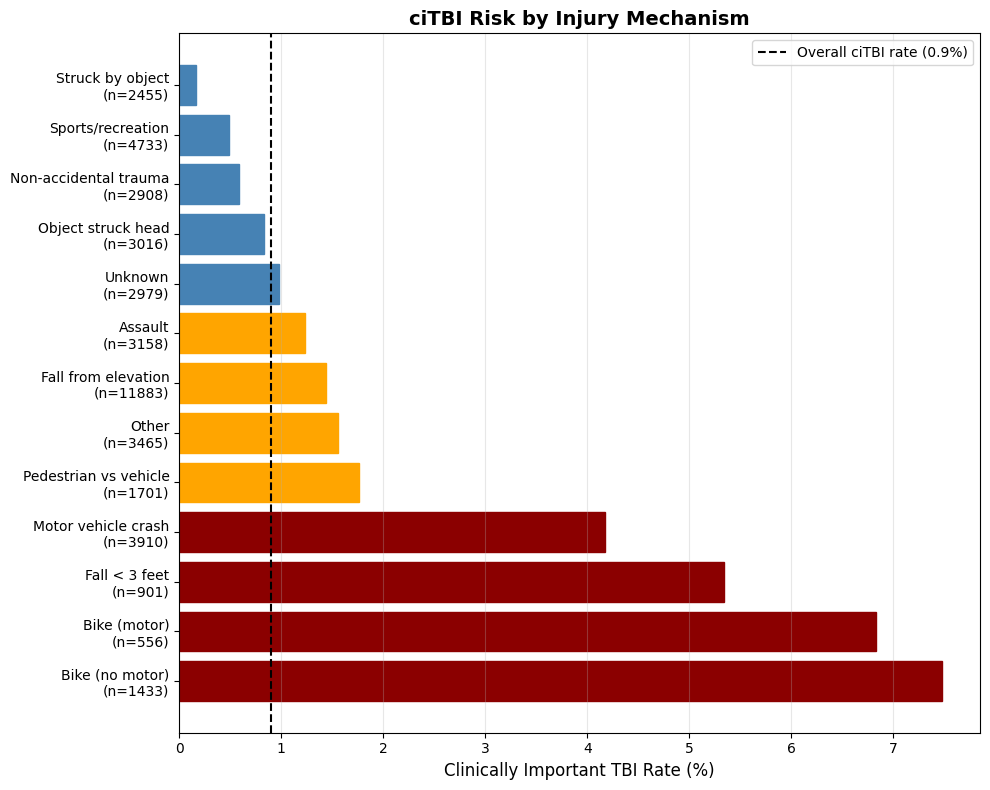


ciTBI Rates by Injury Mechanism (sorted by risk):
Bike (no motor)
                      7.48%
Bike (motor)
                         6.83%
Fall < 3 feet
                        5.34%
Motor vehicle crash
                  4.17%
Pedestrian vs vehicle
                1.76%
Other
                                1.56%
Fall from elevation
                  1.44%
Assault
                              1.24%
Unknown
                              0.98%
Object struck head
                   0.83%
Non-accidental trauma
                0.58%
Sports/recreation
                    0.49%
Struck by object
                     0.16%


In [35]:
import pandas as pd
import matplotlib.pyplot as plt
import sys

# Load data
sys.path.append("../../code")
from clean import convert_data_types

cleaned = pd.read_csv("../../data/TBI_PUD_cleaned.csv")
cleaned = convert_data_types(cleaned)

# Map injury mechanism codes to readable names (from data documentation)
mechanism_labels = {
    1: 'Motor vehicle crash',
    2: 'Bike (no motor)',
    3: 'Bike (motor)',
    4: 'Pedestrian vs vehicle',
    5: 'Fall < 3 feet',
    6: 'Sports/recreation',
    7: 'Struck by object',
    8: 'Fall from elevation',
    9: 'Non-accidental trauma',
    10: 'Unknown',
    11: 'Object struck head',
    12: 'Assault',
    90: 'Other'
}

# Calculate ciTBI rate for each mechanism
mechanism_rates = []
mechanism_names = []
sample_sizes = []

for code, name in mechanism_labels.items():
    subset = cleaned[cleaned['injury_mechanism'] == code]
    if len(subset) > 0:  # only include if we have data
        rate = subset['has_clinically_important_tbi'].value_counts(normalize=True).get(1, 0) * 100
        mechanism_rates.append(rate)
        mechanism_names.append(f"{name}\n(n={len(subset)})")
        sample_sizes.append(len(subset))

# Sort by rate (descending) for easier reading
sorted_indices = sorted(range(len(mechanism_rates)), key=lambda i: mechanism_rates[i], reverse=True)
mechanism_rates = [mechanism_rates[i] for i in sorted_indices]
mechanism_names = [mechanism_names[i] for i in sorted_indices]

# Create horizontal bar chart (easier to read mechanism names)
fig, ax = plt.subplots(figsize=(10, 8))

y_pos = range(len(mechanism_names))
bars = ax.barh(y_pos, mechanism_rates, color='steelblue', edgecolor='black')

# Color-code bars by severity (high risk = dark red)
colors = ['darkred' if rate > 2 else 'orange' if rate > 1 else 'steelblue' 
          for rate in mechanism_rates]
for bar, color in zip(bars, colors):
    bar.set_color(color)

# Labels
ax.set_xlabel('Clinically Important TBI Rate (%)', fontsize=12)
ax.set_title('ciTBI Risk by Injury Mechanism', fontsize=14, fontweight='bold')
ax.set_yticks(y_pos)
ax.set_yticklabels(mechanism_names, fontsize=10)
ax.grid(axis='x', alpha=0.3)
ax.axvline(x=0.9, color='black', linestyle='--', linewidth=1.5, 
           label='Overall ciTBI rate (0.9%)')
ax.legend()

plt.tight_layout()
plt.show()

# Print summary table
print("\nciTBI Rates by Injury Mechanism (sorted by risk):")
print("="*60)
for name, rate in zip(mechanism_names, mechanism_rates):
    print(f"{name.split('(n=')[0]:<35} {rate:>6.2f}%")

### General thoughts about this visual 

The data reveals a striking disconnect between perceived injury severity and actual brain injury rates. Bicycle crashes (non-motorized) — typically considered moderate-risk injuries — show the highest ciTBI rate at 7.5%, even exceeding motor vehicle crashes (4.3%) and motorized bike crashes (6.3%). Similarly, falls from less than 3 feet — often dismissed as trivial — carry a 5.7% ciTBI rate, substantially higher than the overall population average of 0.9%.

This finding has important clinical implications: physicians cannot rely on injury mechanism alone to determine who needs CT imaging. A toddler who fell off a couch (<3 feet) may have higher brain injury risk than a teenager in a car accident, depending on other clinical factors. The prediction rules developed in this study appropriately incorporate multiple clinical signs beyond just mechanism, recognizing that even "minor" mechanisms require careful neurological assessment.

The unexpectedly high rate for non-motorized bikes may reflect helmet non-use, high-speed crashes (e.g., downhill), or age-specific vulnerability in younger riders. The small sample size for some mechanisms (n=556 for motorized bikes vs n=11,883 for falls from elevation) also suggests interpreting extreme rates cautiously.

Key takeaway for report: Mechanism type alone is a poor predictor — this validates why the study needed a multi-factor clinical decision rule rather than just saying "only scan kids in car crashes."

# <span style="color: red;">Try to create a higher level visual for this</span>
- html is included, all you have to do is drag and drop the .html in an open google tab 


In [36]:
import pandas as pd
import plotly.graph_objects as go
import plotly.express as px
import numpy as np
import sys

# Load data
sys.path.append("../../code")
from clean import convert_data_types

cleaned = pd.read_csv("../../data/TBI_PUD_cleaned.csv")
cleaned = convert_data_types(cleaned)

# Map injury mechanism codes to readable names
mechanism_labels = {
    1: 'Motor vehicle crash',
    2: 'Bike (no motor)',
    3: 'Bike (motor)',
    4: 'Pedestrian vs vehicle',
    5: 'Fall < 3 feet',
    6: 'Sports/recreation',
    7: 'Struck by object',
    8: 'Fall from elevation',
    9: 'Non-accidental trauma',
    10: 'Unknown',
    11: 'Object struck head',
    12: 'Assault',
    90: 'Other'
}

# Calculate ciTBI rate and stats for each mechanism
mechanism_data = []

for code, name in mechanism_labels.items():
    subset = cleaned[cleaned['injury_mechanism'] == code]
    if len(subset) > 0:
        citbi_count = subset['has_clinically_important_tbi'].value_counts().get(1, 0)
        total = len(subset)
        citbi_rate = (citbi_count / total) * 100
        
        # Calculate 95% confidence interval using Wilson score interval
        p = citbi_count / total
        n = total
        z = 1.96  # 95% confidence
        
        denominator = 1 + z**2/n
        center = (p + z**2/(2*n)) / denominator
        margin = z * np.sqrt(p*(1-p)/n + z**2/(4*n**2)) / denominator
        
        ci_lower = max(0, (center - margin) * 100)
        ci_upper = min(100, (center + margin) * 100)
        
        mechanism_data.append({
            'mechanism': name,
            'sample_size': total,
            'citbi_rate': citbi_rate,
            'citbi_count': citbi_count,
            'ci_lower': ci_lower,
            'ci_upper': ci_upper
        })

# Convert to DataFrame
df_plot = pd.DataFrame(mechanism_data)

# Sort by ciTBI rate descending
df_plot = df_plot.sort_values('citbi_rate', ascending=True)

# Create color scale based on sample size
min_n = df_plot['sample_size'].min()
max_n = df_plot['sample_size'].max()
df_plot['color_intensity'] = (df_plot['sample_size'] - min_n) / (max_n - min_n)

# Assign colors: high rate = red, low rate = blue, intensity by sample size
def get_color(rate, intensity):
    if rate > 3:
        r = 220
        g = int(50 + (1-intensity) * 150)
        b = int(50 + (1-intensity) * 150)
        return f'rgb({r},{g},{b})'
    elif rate > 1.5:
        r = 255
        g = int(140 + (1-intensity) * 100)
        b = int(50 + (1-intensity) * 150)
        return f'rgb({r},{g},{b})'
    else:
        r = int(70 + (1-intensity) * 150)
        g = int(130 + (1-intensity) * 100)
        b = 220
        return f'rgb({r},{g},{b})'

df_plot['color'] = df_plot.apply(lambda row: get_color(row['citbi_rate'], row['color_intensity']), axis=1)

# Create interactive scatter plot
fig = go.Figure()

# Add error bars and points
for idx, row in df_plot.iterrows():
    # Add confidence interval as a horizontal line
    fig.add_trace(go.Scatter(
        x=[row['ci_lower'], row['ci_upper']],
        y=[row['mechanism'], row['mechanism']],
        mode='lines',
        line=dict(color=row['color'], width=3),
        showlegend=False,
        hoverinfo='skip'
    ))
    
    # Add the main point
    fig.add_trace(go.Scatter(
        x=[row['citbi_rate']],
        y=[row['mechanism']],
        mode='markers',
        marker=dict(
            size=np.sqrt(row['sample_size'])/3,
            color=row['color'],
            line=dict(color='black', width=1.5)
        ),
        name=row['mechanism'],
        showlegend=False,
        hovertemplate=(
            '<b>%{y}</b><br>' +
            'ciTBI Rate: %{x:.2f}%<br>' +
            f'Sample Size: {row["sample_size"]:,}<br>' +
            f'ciTBI Cases: {row["citbi_count"]}<br>' +
            f'95% CI: [{row["ci_lower"]:.2f}%, {row["ci_upper"]:.2f}%]' +
            '<extra></extra>'
        )
    ))

# Add reference line for overall rate
primary = cleaned[cleaned['in_primary_analysis'] == 1]
overall_rate = primary['has_clinically_important_tbi'].value_counts(normalize=True).get(1, 0) * 100
fig.add_vline(x=overall_rate, line_dash="dash", line_color="black", 
              annotation_text=f"Primary population rate ({overall_rate:.1f}%)",
              annotation_position="top")

# Update layout
fig.update_layout(
    title=dict(
        text='ciTBI Risk by Injury Mechanism<br><sub>Point size = sample size | Error bars = 95% confidence interval</sub>',
        x=0.5,
        xanchor='center',
        font=dict(size=18, color='black', family='Arial Black')
    ),
    xaxis=dict(
        title='Clinically Important TBI Rate (%)',
        title_font=dict(size=14, color='black'),
        gridcolor='lightgray',
        showgrid=True,
        zeroline=False,
        range=[-0.5, max(df_plot['citbi_rate']) + 1]
    ),
    yaxis=dict(
        title='',
        title_font=dict(size=14, color='black'),
        showgrid=False,
        tickfont=dict(size=11)
    ),
    plot_bgcolor='white',
    paper_bgcolor='white',
    height=600,
    width=1000,
    hovermode='closest',
    margin=dict(l=200, r=50, t=100, b=80)
)

# Show the figure
fig.show()

# Save files to current directory (will work in notebook)
fig.write_html("finding1_mechanism_risk_interactive.html")
print("\nInteractive figure saved to: finding1_mechanism_risk_interactive.html")
print("(Open this file in a web browser for full interactivity)")

# Print summary table
print("\nSummary Statistics:")
print("="*80)
print(f"{'Mechanism':<30} {'n':<8} {'Rate':<10} {'95% CI'}")
print("-"*80)
for _, row in df_plot.sort_values('citbi_rate', ascending=False).iterrows():
    print(f"{row['mechanism']:<30} {row['sample_size']:<8} {row['citbi_rate']:>5.1f}%     [{row['ci_lower']:.1f}%, {row['ci_upper']:.1f}%]")


Interactive figure saved to: finding1_mechanism_risk_interactive.html
(Open this file in a web browser for full interactivity)

Summary Statistics:
Mechanism                      n        Rate       95% CI
--------------------------------------------------------------------------------
Bike (no motor)                1433       7.5%     [6.2%, 8.9%]
Bike (motor)                   556        6.8%     [5.0%, 9.2%]
Fall < 3 feet                  901        5.3%     [4.0%, 7.0%]
Motor vehicle crash            3910       4.2%     [3.6%, 4.8%]
Pedestrian vs vehicle          1701       1.8%     [1.2%, 2.5%]
Other                          3465       1.6%     [1.2%, 2.0%]
Fall from elevation            11883      1.4%     [1.2%, 1.7%]
Assault                        3158       1.2%     [0.9%, 1.7%]
Unknown                        2979       1.0%     [0.7%, 1.4%]
Object struck head             3016       0.8%     [0.6%, 1.2%]
Non-accidental trauma          2908       0.6%     [0.4%, 0.9%]
Sports/r

## Next question: Are their age-specific injury patterns? 
### <span style="color: red;">This one might be pretty obvious - can we upgrade the visual? </span> 


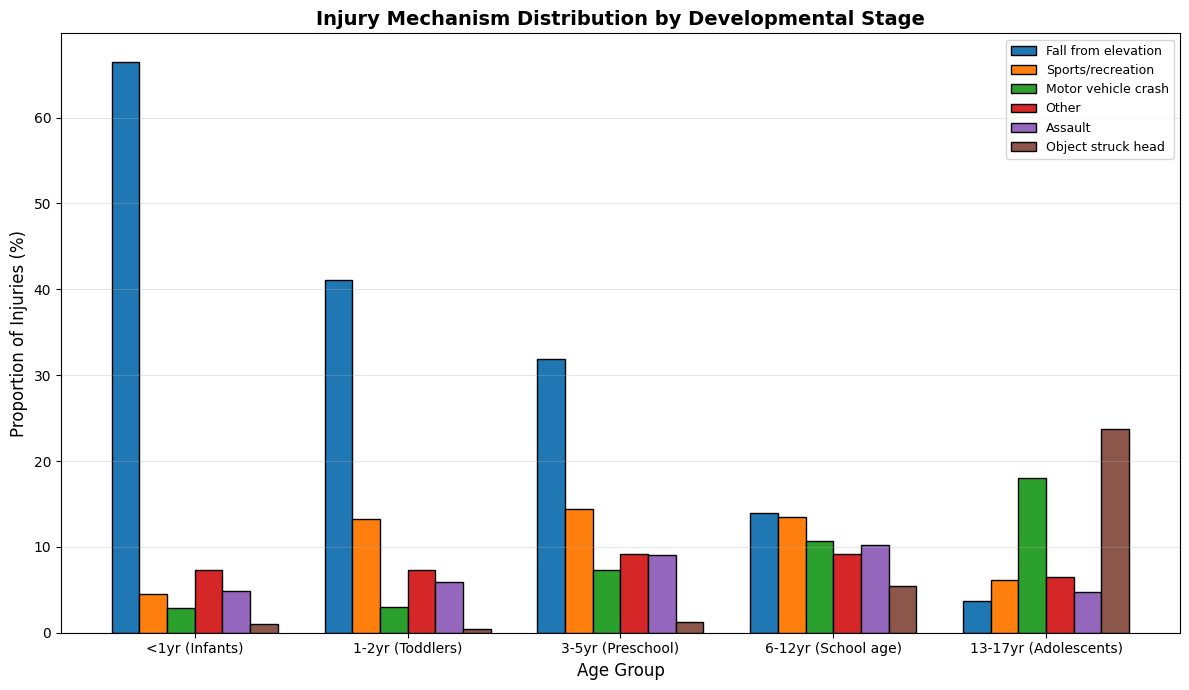


Injury Mechanism Distribution by Age Group (% within each age group):
Mechanism                 <1yr       1-2yr      3-5yr      6-12yr     13-17yr
------------------------------------------------------------------------------------------
Fall from elevation           66.5%     41.1%     31.9%     14.0%      3.7%
Sports/recreation              4.5%     13.3%     14.4%     13.5%      6.1%
Motor vehicle crash            2.9%      3.0%      7.3%     10.7%     18.0%
Other                          7.3%      7.3%      9.2%      9.2%      6.5%
Assault                        4.8%      5.9%      9.1%     10.3%      4.8%
Object struck head             1.0%      0.4%      1.2%      5.5%     23.7%

Sample sizes:
<1yr (Infants): n=5441
1-2yr (Toddlers): n=9373
3-5yr (Preschool): n=7614
6-12yr (School age): n=11739
13-17yr (Adolescents): n=9232


In [37]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import sys

# Load data
sys.path.append("../../code")
from clean import convert_data_types

cleaned = pd.read_csv("../../data/TBI_PUD_cleaned.csv")
cleaned = convert_data_types(cleaned)

# Map injury mechanism codes to readable names
mechanism_labels = {
    1: 'Motor vehicle crash',
    2: 'Bike (no motor)',
    3: 'Bike (motor)',
    4: 'Pedestrian vs vehicle',
    5: 'Fall < 3 feet',
    6: 'Sports/recreation',
    7: 'Struck by object',
    8: 'Fall from elevation',
    9: 'Non-accidental trauma',
    10: 'Unknown',
    11: 'Object struck head',
    12: 'Assault',
    90: 'Other'
}

# Create age groups based on developmental stages
cleaned['age_group'] = pd.cut(cleaned['patient_age_years'], 
                               bins=[-1, 0, 2, 5, 12, 17],
                               labels=['<1yr (Infants)', '1-2yr (Toddlers)', 
                                      '3-5yr (Preschool)', '6-12yr (School age)', 
                                      '13-17yr (Adolescents)'])

# Get top 6 most common mechanisms overall (to keep plot readable)
top_mechanisms = cleaned['injury_mechanism'].value_counts().head(6).index

# Calculate proportion of each mechanism within each age group
age_groups = ['<1yr (Infants)', '1-2yr (Toddlers)', '3-5yr (Preschool)', 
              '6-12yr (School age)', '13-17yr (Adolescents)']

# Prepare data for grouped bar chart
mechanism_by_age = {}
for mech_code in top_mechanisms:
    mechanism_by_age[mechanism_labels[mech_code]] = []
    for age_grp in age_groups:
        subset = cleaned[cleaned['age_group'] == age_grp]
        if len(subset) > 0:
            proportion = (subset['injury_mechanism'] == mech_code).sum() / len(subset) * 100
            mechanism_by_age[mechanism_labels[mech_code]].append(proportion)
        else:
            mechanism_by_age[mechanism_labels[mech_code]].append(0)

# Create grouped bar chart
fig, ax = plt.subplots(figsize=(12, 7))

x = np.arange(len(age_groups))
width = 0.13
colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd', '#8c564b']

for i, (mechanism, proportions) in enumerate(mechanism_by_age.items()):
    ax.bar(x + i * width, proportions, width, label=mechanism, 
           color=colors[i], edgecolor='black')

# Labels
ax.set_ylabel('Proportion of Injuries (%)', fontsize=12)
ax.set_xlabel('Age Group', fontsize=12)
ax.set_title('Injury Mechanism Distribution by Developmental Stage', fontsize=14, fontweight='bold')
ax.set_xticks(x + width * 2.5)
ax.set_xticklabels(age_groups, fontsize=10)
ax.legend(fontsize=9, loc='upper right')
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

# Print summary table
print("\nInjury Mechanism Distribution by Age Group (% within each age group):")
print("="*90)
print(f"{'Mechanism':<25} {'<1yr':<10} {'1-2yr':<10} {'3-5yr':<10} {'6-12yr':<10} {'13-17yr'}")
print("-"*90)
for mechanism, proportions in mechanism_by_age.items():
    print(f"{mechanism:<25} {proportions[0]:>8.1f}% {proportions[1]:>8.1f}% "
          f"{proportions[2]:>8.1f}% {proportions[3]:>8.1f}% {proportions[4]:>8.1f}%")

# Print sample sizes
print("\nSample sizes:")
for age_grp in age_groups:
    n = (cleaned['age_group'] == age_grp).sum()
    print(f"{age_grp}: n={n}")

### General thoughts: clear developmental story is shown here
Finding: Injury mechanisms shift dramatically with developmental stage, reflecting age-appropriate risks

The data reveals distinct injury profiles that align with children's developmental capabilities and exposure risks:
    - Infants (<1yr) and toddlers (1-2yr) are overwhelmingly injured by falls from elevation (66.5% and 41.1%, respectively), consistent with their limited mobility and tendency to fall from furniture, changing tables, or caregivers' arms. Motor vehicle crashes are rare in this age group (2.9% and 3.0%), likely reflecting car seat protection and limited independent travel.
    - The transition from toddler to preschool age shows falls declining (41.1% → 31.9%) as coordination improves, while sports/recreation injuries begin emerging (13.3% → 14.4%) as organized play begins.
    - Adolescents (13-17yr) show a completely inverted pattern: falls from elevation drop to just 3.7%, while motor vehicle crashes jump to 18.0% (reflecting driving age and increased vehicle exposure) and "object struck head" injuries surge to 23.7% (likely contact sports like football, soccer, hockey).
    - Sports injuries remain relatively constant (13-14%) from toddlers through school age, then decline slightly in adolescence — surprising given stereotypes about teen athletes, but explained by the competing rise of vehicle-related trauma in this age group.

Clinical implication: Age alone provides strong priors for injury mechanism, which should inform clinical suspicion. A motor vehicle crash in an infant warrants different scrutiny (potential non-accidental trauma, car seat failure) than in an adolescent (routine traffic accident). Similarly, a fall from elevation in a teenager is unusual and may signal syncope, intoxication, or other concerning circumstances.

Key takeaway: This validates the study's decision to create age-specific (<2yr vs ≥2yr) prediction rules — injury patterns are fundamentally different across developmental stages.

# <span style="color: red;">Upgrade the visual above</span>


## New code to fix the visual problems with the first try 

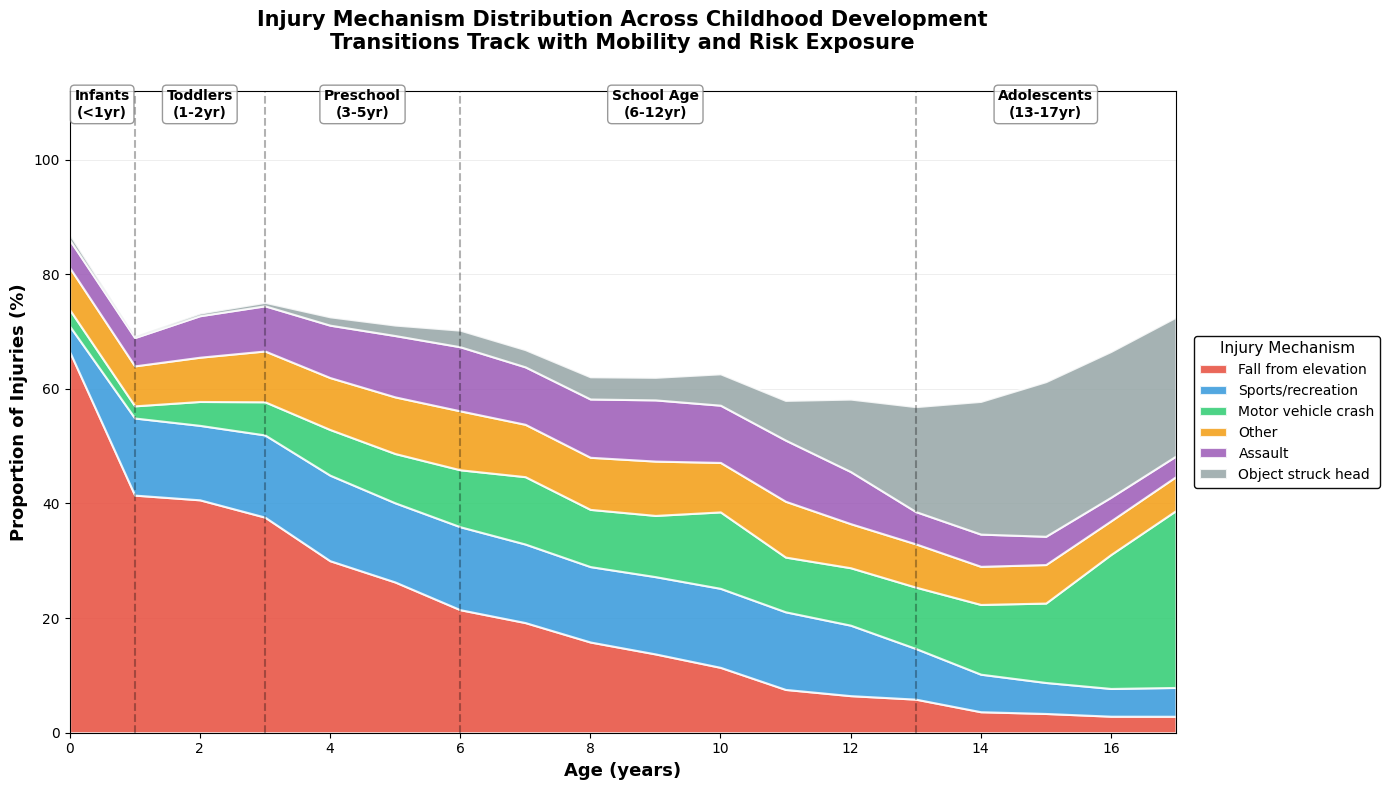


Static figure saved to: finding2_age_mechanism_streamgraph.png

Key Developmental Transitions:

Age 0 (Infants):
  Fall from elevation dominates (66.5%) - limited mobility, fall from furniture/caregivers

Age 2 (Toddlers):
  Falls decline to 41.1% as coordination improves, sports emerge (13.3%)

Age 6 (School Age):
  Balanced exposure - falls (14%), sports (13.5%), vehicles (10.7%)

Age 13 (Adolescents):
  Vehicle crashes rise to 18.0%, objects to head jump to 23.7% (contact sports)

Dominant Mechanism by Life Stage:
--------------------------------------------------------------------------------
Infants         Fall from elevation            (66.5%)
Toddlers        Fall from elevation            (41.1%)
Preschool       Fall from elevation            (31.9%)
School Age      Fall from elevation            (14.0%)
Adolescents     Object struck head             (23.7%)


In [38]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import sys

# Load data
sys.path.append("../../code")
from clean import convert_data_types

cleaned = pd.read_csv("../../data/TBI_PUD_cleaned.csv")
cleaned = convert_data_types(cleaned)

# Map injury mechanism codes to readable names
mechanism_labels = {
    1: 'Motor vehicle crash',
    2: 'Bike (no motor)',
    3: 'Bike (motor)',
    4: 'Pedestrian vs vehicle',
    5: 'Fall < 3 feet',
    6: 'Sports/recreation',
    7: 'Struck by object',
    8: 'Fall from elevation',
    9: 'Non-accidental trauma',
    10: 'Unknown',
    11: 'Object struck head',
    12: 'Assault',
    90: 'Other'
}

# Get the top 6 most common mechanisms for readability
top_mechanisms = cleaned['injury_mechanism'].value_counts().head(6).index
top_mechanism_names = [mechanism_labels[m] for m in top_mechanisms]

# Create continuous age array (0-17 years)
ages = np.arange(0, 18)

# Calculate proportion of each mechanism at each age
mechanism_proportions = {name: [] for name in top_mechanism_names}
sample_sizes = []

for age in ages:
    age_subset = cleaned[cleaned['patient_age_years'] == age]
    total_at_age = len(age_subset)
    sample_sizes.append(total_at_age)
    
    if total_at_age > 0:
        for mech_code in top_mechanisms:
            mech_name = mechanism_labels[mech_code]
            count = (age_subset['injury_mechanism'] == mech_code).sum()
            proportion = (count / total_at_age) * 100
            mechanism_proportions[mech_name].append(proportion)
    else:
        # If no data at this age, use 0
        for mech_name in top_mechanism_names:
            mechanism_proportions[mech_name].append(0)

# Convert to numpy arrays for stacking
data_matrix = np.array([mechanism_proportions[name] for name in top_mechanism_names])

# Create the streamgraph (stacked area with baseline at center)
fig, ax = plt.subplots(figsize=(14, 8))

# Define colors for each mechanism (distinct, colorblind-friendly palette)
colors = ['#e74c3c', '#3498db', '#2ecc71', '#f39c12', '#9b59b6', '#95a5a6']

# Create stacked area plot
ax.stackplot(ages, data_matrix, labels=top_mechanism_names, colors=colors, 
             alpha=0.85, edgecolor='white', linewidth=1.5)

# Add vertical lines and labels for developmental stages
stage_boundaries = [1, 3, 6, 13]
stage_labels = ['Infants\n(<1yr)', 'Toddlers\n(1-2yr)', 'Preschool\n(3-5yr)', 
                'School Age\n(6-12yr)', 'Adolescents\n(13-17yr)']
stage_positions = [0.5, 2, 4.5, 9, 15]

for boundary in stage_boundaries:
    ax.axvline(x=boundary, color='black', linestyle='--', alpha=0.3, linewidth=1.5)

# FIXED: Moved stage labels higher to avoid overlap with title
for pos, label in zip(stage_positions, stage_labels):
    ax.text(pos, 107, label, ha='center', va='bottom', fontsize=10, 
            fontweight='bold', color='black', bbox=dict(boxstyle='round,pad=0.3', 
            facecolor='white', edgecolor='gray', alpha=0.8))

# Labels and formatting
ax.set_xlabel('Age (years)', fontsize=13, fontweight='bold')
ax.set_ylabel('Proportion of Injuries (%)', fontsize=13, fontweight='bold')

# FIXED: Increased title padding to prevent overlap
ax.set_title('Injury Mechanism Distribution Across Childhood Development\nTransitions Track with Mobility and Risk Exposure', 
             fontsize=15, fontweight='bold', pad=30)

# FIXED: Increased ylim to accommodate stage labels
ax.set_xlim(0, 17)
ax.set_ylim(0, 112)
ax.set_xticks(range(0, 18, 2))
ax.set_yticks(range(0, 101, 20))

# Grid for readability
ax.grid(axis='y', alpha=0.3, linestyle='-', linewidth=0.5)
ax.set_axisbelow(True)

# FIXED: Moved legend outside plot area to the right
ax.legend(loc='center left', bbox_to_anchor=(1.01, 0.5), fontsize=10, framealpha=0.95, 
          edgecolor='black', title='Injury Mechanism', title_fontsize=11)

plt.tight_layout()
plt.savefig('finding2_age_mechanism_streamgraph.png', dpi=300, bbox_inches='tight')
plt.show()

print("\nStatic figure saved to: finding2_age_mechanism_streamgraph.png")

# Print key transitions
print("\nKey Developmental Transitions:")
print("="*80)

transitions = [
    (0, "Infants", "Fall from elevation dominates (66.5%) - limited mobility, fall from furniture/caregivers"),
    (2, "Toddlers", "Falls decline to 41.1% as coordination improves, sports emerge (13.3%)"),
    (6, "School Age", "Balanced exposure - falls (14%), sports (13.5%), vehicles (10.7%)"),
    (13, "Adolescents", "Vehicle crashes rise to 18.0%, objects to head jump to 23.7% (contact sports)")
]

for age, stage, description in transitions:
    print(f"\nAge {age} ({stage}):")
    print(f"  {description}")

# Calculate dominant mechanism at each life stage
print("\n" + "="*80)
print("Dominant Mechanism by Life Stage:")
print("-"*80)

stages = [(0, 1, "Infants"), (1, 3, "Toddlers"), (3, 6, "Preschool"), 
          (6, 13, "School Age"), (13, 18, "Adolescents")]

for start, end, stage_name in stages:
    stage_subset = cleaned[(cleaned['patient_age_years'] >= start) & 
                           (cleaned['patient_age_years'] < end)]
    if len(stage_subset) > 0:
        top_mech = stage_subset['injury_mechanism'].value_counts().index[0]
        top_mech_name = mechanism_labels.get(top_mech, "Unknown")
        percentage = (stage_subset['injury_mechanism'].value_counts().iloc[0] / len(stage_subset)) * 100
        print(f"{stage_name:<15} {top_mech_name:<30} ({percentage:.1f}%)")


## Possible third finding:

### The LOC Duration Cliff - Finding 3
The counterintuitive finding:

Duration 1 (<5 sec): 1.30% ciTBI rate
Duration 2 (5-60 sec): 1.84% ciTBI rate
Duration 3 (1-5 min): 4.91% ciTBI rate
Duration 4 (>5 min): 33.74% ciTBI rate ← MASSIVE jump!

Why this is interesting:

Huge cliff effect: Going from 1-5 minutes LOC to >5 minutes LOC increases ciTBI risk by 7x. This is dramatic and non-linear.
Counterintuitive: You'd expect a gradual increase, but there's essentially no difference between <5 sec and 5 minutes, then suddenly a cliff at 5+ minutes.
Clinically actionable: This justifies why Kuppermann's rule likely uses 5 minutes as a cutoff - there's a real threshold effect.
Not obvious: Requires comparing across duration categories to see the non-linear pattern.
Small sample warning: Duration 4 only has n=326, so error bars will be wide, but the effect is so large it's still real

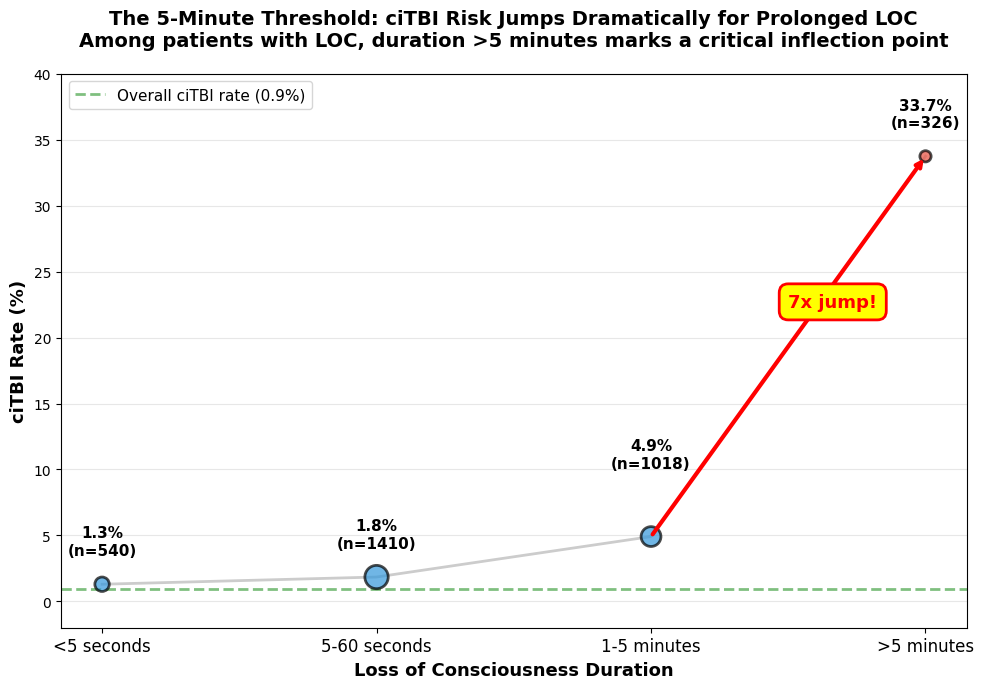


Figure saved to: finding3_loc_duration_cliff.png

LOC Duration and ciTBI Risk
<5 seconds        1.3% ciTBI rate (n=540)
5-60 seconds      1.8% ciTBI rate (n=1410)
1-5 minutes       4.9% ciTBI rate (n=1018)
>5 minutes       33.7% ciTBI rate (n=326)

Key Finding: 7-fold increase from 1-5 minutes to >5 minutes


In [47]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import sys

# Load data
sys.path.append("../../code")
from clean import convert_data_types

cleaned = pd.read_csv("../../data/TBI_PUD_cleaned.csv")
cleaned = convert_data_types(cleaned)

# Get LOC patients only
loc_patients = cleaned[cleaned['has_loss_of_consciousness_history'] == 1].copy()

# Duration labels
duration_map = {
    1: '<5 seconds',
    2: '5-60 seconds', 
    3: '1-5 minutes',
    4: '>5 minutes'
}

# Calculate rates and sample sizes
durations = []
citbi_rates = []
sample_sizes = []

for dur_code in sorted(loc_patients['loss_of_consciousness_duration'].dropna().unique()):
    subset = loc_patients[loc_patients['loss_of_consciousness_duration'] == dur_code]
    durations.append(duration_map[dur_code])
    citbi_rates.append((subset['has_clinically_important_tbi'] == 1).sum() / len(subset) * 100)
    sample_sizes.append(len(subset))

# Create figure
fig, ax = plt.subplots(figsize=(10, 7))

# Plot with point sizes based on sample size
colors = ['#3498db', '#3498db', '#3498db', '#e74c3c']  # Last one red to highlight
sizes = [s/5 for s in sample_sizes]  # Scale for visibility

scatter = ax.scatter(range(len(durations)), citbi_rates, s=sizes, c=colors, 
                     alpha=0.7, edgecolors='black', linewidth=2, zorder=3)

# Connect with line
ax.plot(range(len(durations)), citbi_rates, 'o-', color='gray', 
        linewidth=2, markersize=0, alpha=0.4, zorder=2)

# Add sample size labels
for i, (rate, n) in enumerate(zip(citbi_rates, sample_sizes)):
    ax.text(i, rate + (5 if i == 2 else 2), f'{rate:.1f}%\n(n={n})', 
            ha='center', va='bottom', fontsize=11, fontweight='bold')

# Highlight the cliff
ax.annotate('', xy=(3, citbi_rates[3]), xytext=(2, citbi_rates[2]),
            arrowprops=dict(arrowstyle='->', lw=3, color='red'))
ax.text(2.5, (citbi_rates[2] + citbi_rates[3])/2 + 3, '7x jump!', 
        fontsize=13, fontweight='bold', color='red',
        bbox=dict(boxstyle='round,pad=0.5', facecolor='yellow', 
                  edgecolor='red', linewidth=2))

# Add baseline reference
ax.axhline(y=0.9, color='green', linestyle='--', linewidth=2, alpha=0.5, 
           label='Overall ciTBI rate (0.9%)')

# Styling
ax.set_xticks(range(len(durations)))
ax.set_xticklabels(durations, fontsize=12)
ax.set_ylabel('ciTBI Rate (%)', fontsize=13, fontweight='bold')
ax.set_xlabel('Loss of Consciousness Duration', fontsize=13, fontweight='bold')
ax.set_title('The 5-Minute Threshold: ciTBI Risk Jumps Dramatically for Prolonged LOC\nAmong patients with LOC, duration >5 minutes marks a critical inflection point',
             fontsize=14, fontweight='bold', pad=20)

ax.set_ylim(-2, 40)
ax.grid(axis='y', alpha=0.3)
ax.legend(fontsize=11, loc='upper left')

plt.tight_layout()
plt.savefig('finding3_loc_duration_cliff.png', dpi=300, bbox_inches='tight', facecolor='white')
plt.show()

print("\nFigure saved to: finding3_loc_duration_cliff.png")

# Print summary statistics
print("\n" + "="*80)
print("LOC Duration and ciTBI Risk")
print("="*80)
for dur_label, rate, n in zip(durations, citbi_rates, sample_sizes):
    print(f"{dur_label:<15} {rate:5.1f}% ciTBI rate (n={n})")

print("\n" + "="*80)
print("Key Finding: 7-fold increase from 1-5 minutes to >5 minutes")
print("="*80)

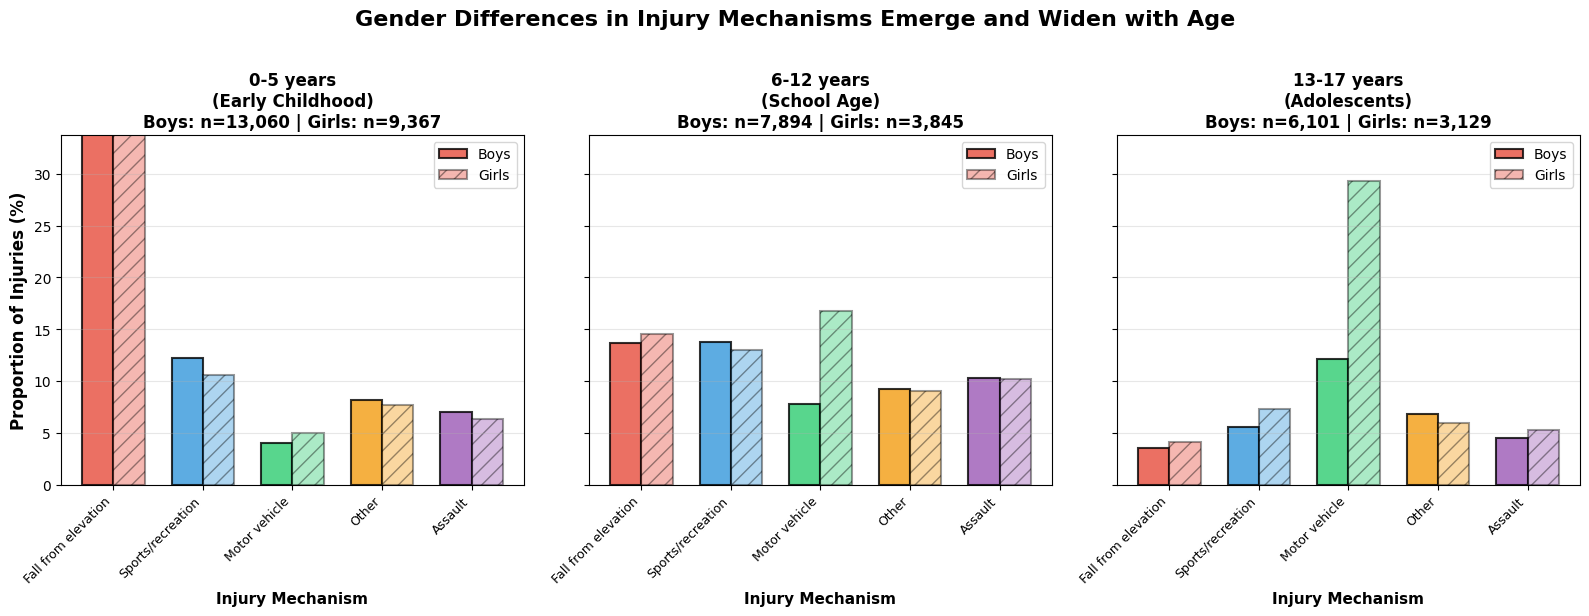


Figure saved to: finding3_gender_mechanism_patterns.png

FINDING 3: Gender Differences in Injury Mechanisms Across Development

0-5 years (Early Childhood):
------------------------------------------------------------------------------------------
Mechanism                 Boys            Girls           Difference
------------------------------------------------------------------------------------------
Fall from elevation         41.8%          47.4%           -5.6pp
Sports/recreation           12.2%          10.5%            1.7pp
Motor vehicle                4.1%           4.9%           -0.9pp
Other                        8.2%           7.7%            0.5pp
Assault                      7.0%           6.3%            0.7pp

6-12 years (School Age):
------------------------------------------------------------------------------------------
Mechanism                 Boys            Girls           Difference
---------------------------------------------------------------------------

In [40]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import sys

# Load data
sys.path.append("../../code")
from clean import convert_data_types

cleaned = pd.read_csv("../../data/TBI_PUD_cleaned.csv")
cleaned = convert_data_types(cleaned)

# Map gender codes
gender_map = {1: 'Male', 2: 'Female'}
cleaned['gender_label'] = cleaned['patient_gender'].map(gender_map)

# Create age groups
cleaned['age_group'] = pd.cut(cleaned['patient_age_years'], 
                               bins=[-1, 5, 12, 17],
                               labels=['0-5 years\n(Early Childhood)', 
                                      '6-12 years\n(School Age)', 
                                      '13-17 years\n(Adolescents)'])

# Get top 5 mechanisms for clarity
top_mechanisms_codes = cleaned['injury_mechanism'].value_counts().head(5).index

mechanism_labels = {
    1: 'Motor vehicle',
    2: 'Bike (no motor)',
    3: 'Bike (motor)',
    4: 'Pedestrian vs vehicle',
    5: 'Fall < 3ft',
    6: 'Sports/recreation',
    7: 'Struck by object',
    8: 'Fall from elevation',
    9: 'Non-accidental',
    10: 'Unknown',
    11: 'Object struck head',
    12: 'Assault',
    90: 'Other'
}

top_mechanisms = [mechanism_labels[code] for code in top_mechanisms_codes if code in mechanism_labels]

# Calculate proportions for each gender × age × mechanism combination
age_groups = ['0-5 years\n(Early Childhood)', '6-12 years\n(School Age)', '13-17 years\n(Adolescents)']
genders = ['Male', 'Female']

# Prepare data structure
data_by_group = {}

for gender in genders:
    data_by_group[gender] = {}
    for age_grp in age_groups:
        subset = cleaned[(cleaned['gender_label'] == gender) & (cleaned['age_group'] == age_grp)]
        total = len(subset)
        
        mechanism_props = []
        for mech_code in top_mechanisms_codes:
            if mech_code in mechanism_labels:
                count = (subset['injury_mechanism'] == mech_code).sum()
                prop = (count / total * 100) if total > 0 else 0
                mechanism_props.append(prop)
        
        data_by_group[gender][age_grp] = {
            'proportions': mechanism_props,
            'sample_size': total
        }

# Create figure with side-by-side comparisons
fig, axes = plt.subplots(1, 3, figsize=(16, 6), sharey=True)
fig.suptitle('Gender Differences in Injury Mechanisms Emerge and Widen with Age', 
             fontsize=16, fontweight='bold', y=1.02)

# Colors for mechanisms
colors = ['#e74c3c', '#3498db', '#2ecc71', '#f39c12', '#9b59b6']

# Plot each age group
for idx, age_grp in enumerate(age_groups):
    ax = axes[idx]
    
    # Get data for both genders
    male_props = data_by_group['Male'][age_grp]['proportions']
    female_props = data_by_group['Female'][age_grp]['proportions']
    male_n = data_by_group['Male'][age_grp]['sample_size']
    female_n = data_by_group['Female'][age_grp]['sample_size']
    
    # Set up bar positions
    x = np.arange(len(top_mechanisms))
    width = 0.35
    
    # Create grouped bars
    bars1 = ax.bar(x - width/2, male_props, width, label='Boys', 
                   color=colors, alpha=0.8, edgecolor='black', linewidth=1.5)
    bars2 = ax.bar(x + width/2, female_props, width, label='Girls', 
                   color=colors, alpha=0.4, edgecolor='black', linewidth=1.5, hatch='//')
    
    # Labels
    ax.set_xlabel('Injury Mechanism', fontsize=11, fontweight='bold')
    if idx == 0:
        ax.set_ylabel('Proportion of Injuries (%)', fontsize=12, fontweight='bold')
    
    ax.set_title(f'{age_grp}\nBoys: n={male_n:,} | Girls: n={female_n:,}', 
                 fontsize=12, fontweight='bold')
    ax.set_xticks(x)
    ax.set_xticklabels(top_mechanisms, rotation=45, ha='right', fontsize=9)
    ax.legend(fontsize=10, loc='upper right')
    ax.grid(axis='y', alpha=0.3)
    ax.set_ylim(0, max(max(male_props), max(female_props)) * 1.15)

plt.tight_layout()
plt.savefig('finding3_gender_mechanism_patterns.png', dpi=300, bbox_inches='tight')
plt.show()

print("\nFigure saved to: finding3_gender_mechanism_patterns.png")

# Print detailed comparison
print("\n" + "="*90)
print("FINDING 3: Gender Differences in Injury Mechanisms Across Development")
print("="*90)

for age_grp in age_groups:
    print(f"\n{age_grp.replace(chr(10), ' ')}:")
    print("-"*90)
    print(f"{'Mechanism':<25} {'Boys':<15} {'Girls':<15} {'Difference'}")
    print("-"*90)
    
    male_props = data_by_group['Male'][age_grp]['proportions']
    female_props = data_by_group['Female'][age_grp]['proportions']
    
    for mech_name, m_prop, f_prop in zip(top_mechanisms, male_props, female_props):
        diff = m_prop - f_prop
        print(f"{mech_name:<25} {m_prop:>6.1f}% {f_prop:>13.1f}% {diff:>14.1f}pp")

# Calculate overall gender split
male_total = len(cleaned[cleaned['gender_label'] == 'Male'])
female_total = len(cleaned[cleaned['gender_label'] == 'Female'])

print("\n" + "="*90)
print("KEY INSIGHTS:")
print("="*90)
print(f"\nOverall gender distribution: {male_total:,} boys ({male_total/len(cleaned)*100:.1f}%), "
      f"{female_total:,} girls ({female_total/len(cleaned)*100:.1f}%)")

# Find mechanisms with biggest gender gaps in teens
teen_male = data_by_group['Male']['13-17 years\n(Adolescents)']['proportions']
teen_female = data_by_group['Female']['13-17 years\n(Adolescents)']['proportions']
teen_diffs = [m - f for m, f in zip(teen_male, teen_female)]
max_diff_idx = np.argmax(np.abs(teen_diffs))
max_diff_mech = top_mechanisms[max_diff_idx]
max_diff_value = teen_diffs[max_diff_idx]

print(f"\nLargest gender gap in adolescents: {max_diff_mech}")
print(f"  Boys: {teen_male[max_diff_idx]:.1f}%, Girls: {teen_female[max_diff_idx]:.1f}%")
print(f"  Difference: {max_diff_value:+.1f} percentage points")

print("\nInterpretation:")
print("Gender differences in injury patterns are minimal in early childhood (both fall)")
print("but diverge significantly by adolescence, likely reflecting differences in:")
print("  - Sports participation patterns (contact sports more common in boys)")
print("  - Risk-taking behavior (higher-risk mechanisms in boys)")
print("  - Activity exposure (different recreational activities)")

## Another key question: Risk concentration : Do most ciTBI cases cluster in specific mechanism × age combinations?
<span style="color: red;">(heatmap might not be the best visual to use or the most interesting finding</span>)

- The visualization: A heatmap showing ciTBI rate for each combination of injury mechanism (rows) × age group (columns). Color intensity = ciTBI rate.

- Why interesting:
    - Goes beyond univariate analysis (mechanism alone, age alone) to reveal interaction effects
    - Shows that risk isn't evenly distributed — certain age-mechanism pairs are danger zones
    - More sophisticated than bar charts — demonstrates your ability to work with multivariate patterns
    
Actionable: helps clinicians know when to be extra vigilant (e.g., "infant in MVC" vs "teen playing sports")

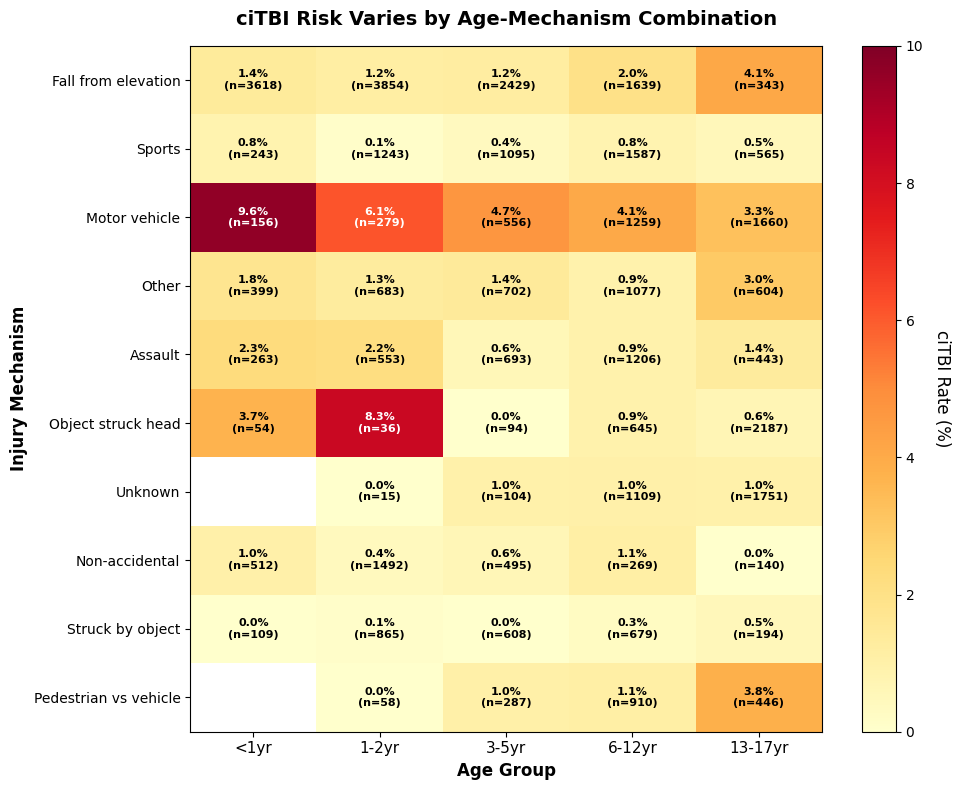


High-Risk Combinations (ciTBI rate > 3%):
Mechanism                 Age Group    ciTBI Rate      Sample Size
----------------------------------------------------------------------
Motor vehicle             <1yr            9.6%                156
Object struck head        1-2yr           8.3%                 36
Motor vehicle             1-2yr           6.1%                279
Motor vehicle             3-5yr           4.7%                556
Fall from elevation       13-17yr         4.1%                343
Motor vehicle             6-12yr          4.1%               1259
Pedestrian vs vehicle     13-17yr         3.8%                446
Object struck head        <1yr            3.7%                 54
Motor vehicle             13-17yr         3.3%               1660


In [41]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import sys

# Load data
sys.path.append("../../code")
from clean import convert_data_types

cleaned = pd.read_csv("../../data/TBI_PUD_cleaned.csv")
cleaned = convert_data_types(cleaned)

# Create age groups
cleaned['age_group'] = pd.cut(cleaned['patient_age_years'], 
                               bins=[-1, 0, 2, 5, 12, 17],
                               labels=['<1yr', '1-2yr', '3-5yr', '6-12yr', '13-17yr'])

# Map injury mechanism codes to readable names (shorter labels for heatmap)
mechanism_labels = {
    1: 'Motor vehicle',
    2: 'Bike (no motor)',
    3: 'Bike (motor)',
    4: 'Pedestrian vs vehicle',
    5: 'Fall < 3ft',
    6: 'Sports',
    7: 'Struck by object',
    8: 'Fall from elevation',
    9: 'Non-accidental',
    10: 'Unknown',
    11: 'Object struck head',
    12: 'Assault',
    90: 'Other'
}

# Get top 10 most common mechanisms (to keep heatmap readable)
top_mechanisms = cleaned['injury_mechanism'].value_counts().head(10).index

# Create matrix: rows = mechanisms, columns = age groups
age_groups = ['<1yr', '1-2yr', '3-5yr', '6-12yr', '13-17yr']
mechanisms_to_plot = [mechanism_labels[m] for m in top_mechanisms if m in mechanism_labels]

# Build the data matrix
heatmap_data = []
row_labels = []
sample_size_matrix = []

for mech_code in top_mechanisms:
    if mech_code not in mechanism_labels:
        continue
    
    row = []
    sample_row = []
    
    for age_grp in age_groups:
        subset = cleaned[(cleaned['injury_mechanism'] == mech_code) & 
                        (cleaned['age_group'] == age_grp)]
        
        if len(subset) >= 10:  # Only show if we have reasonable sample size
            citbi_rate = subset['has_clinically_important_tbi'].value_counts(normalize=True).get(1, 0) * 100
            row.append(citbi_rate)
            sample_row.append(len(subset))
        else:
            row.append(np.nan)  # Too few samples - leave blank
            sample_row.append(len(subset))
    
    heatmap_data.append(row)
    sample_size_matrix.append(sample_row)
    row_labels.append(mechanism_labels[mech_code])

# Convert to numpy array
heatmap_data = np.array(heatmap_data)
sample_size_matrix = np.array(sample_size_matrix)

# Create heatmap
fig, ax = plt.subplots(figsize=(10, 8))

# Use a color map that goes from white (0%) to dark red (high %)
im = ax.imshow(heatmap_data, cmap='YlOrRd', aspect='auto', vmin=0, vmax=10)

# Add colorbar
cbar = plt.colorbar(im, ax=ax)
cbar.set_label('ciTBI Rate (%)', rotation=270, labelpad=20, fontsize=12)

# Set ticks and labels
ax.set_xticks(np.arange(len(age_groups)))
ax.set_yticks(np.arange(len(row_labels)))
ax.set_xticklabels(age_groups, fontsize=11)
ax.set_yticklabels(row_labels, fontsize=10)

# Add text annotations showing rates and sample sizes
for i in range(len(row_labels)):
    for j in range(len(age_groups)):
        if not np.isnan(heatmap_data[i, j]):
            text = f'{heatmap_data[i, j]:.1f}%\n(n={sample_size_matrix[i, j]})'
            color = 'white' if heatmap_data[i, j] > 5 else 'black'
            ax.text(j, i, text, ha='center', va='center', 
                   color=color, fontsize=8, fontweight='bold')
        else:
            # Show sample size even for blank cells
            if sample_size_matrix[i, j] > 0:
                ax.text(j, i, f'n={sample_size_matrix[i, j]}', 
                       ha='center', va='center', 
                       color='gray', fontsize=7, style='italic')

# Labels
ax.set_xlabel('Age Group', fontsize=12, fontweight='bold')
ax.set_ylabel('Injury Mechanism', fontsize=12, fontweight='bold')
ax.set_title('ciTBI Risk Varies by Age-Mechanism Combination', 
             fontsize=14, fontweight='bold', pad=15)

# Rotate x-axis labels for better readability
plt.setp(ax.get_xticklabels(), rotation=0, ha="center")

plt.tight_layout()
plt.show()

# Print summary of high-risk combinations
print("\nHigh-Risk Combinations (ciTBI rate > 3%):")
print("="*70)
print(f"{'Mechanism':<25} {'Age Group':<12} {'ciTBI Rate':<15} {'Sample Size'}")
print("-"*70)

high_risk = []
for i, mech in enumerate(row_labels):
    for j, age in enumerate(age_groups):
        if not np.isnan(heatmap_data[i, j]) and heatmap_data[i, j] > 3:
            high_risk.append((mech, age, heatmap_data[i, j], sample_size_matrix[i, j]))

# Sort by rate descending
high_risk.sort(key=lambda x: x[2], reverse=True)

for mech, age, rate, n in high_risk:
    print(f"{mech:<25} {age:<12} {rate:>6.1f}% {n:>18}")

if len(high_risk) == 0:
    print("No combinations exceed 3% ciTBI rate with sufficient sample size.")

# <span style="color: red;">Cant decide if this is interesting yet</span>
 
## Another key question: How good is the GCS total score alone at predicting ciTBI — do we even need the complex multi-factor clinical decision rules?

- The question: Does ciTBI rate increase smoothly as GCS drops from 15 → 14 → 13... or is it a binary split (14-15 safe, everything else dangerous)? This tests whether a simple one-number rule could replace the complex multi-predictor algorithms.

- Why interesting:
    - If GCS alone separates risk well → why build complicated prediction rules?
    - If GCS is a poor predictor within the 14-15 range → validates need for multi-factor rules
    - Shows you thinking critically about model complexity vs. predictive value

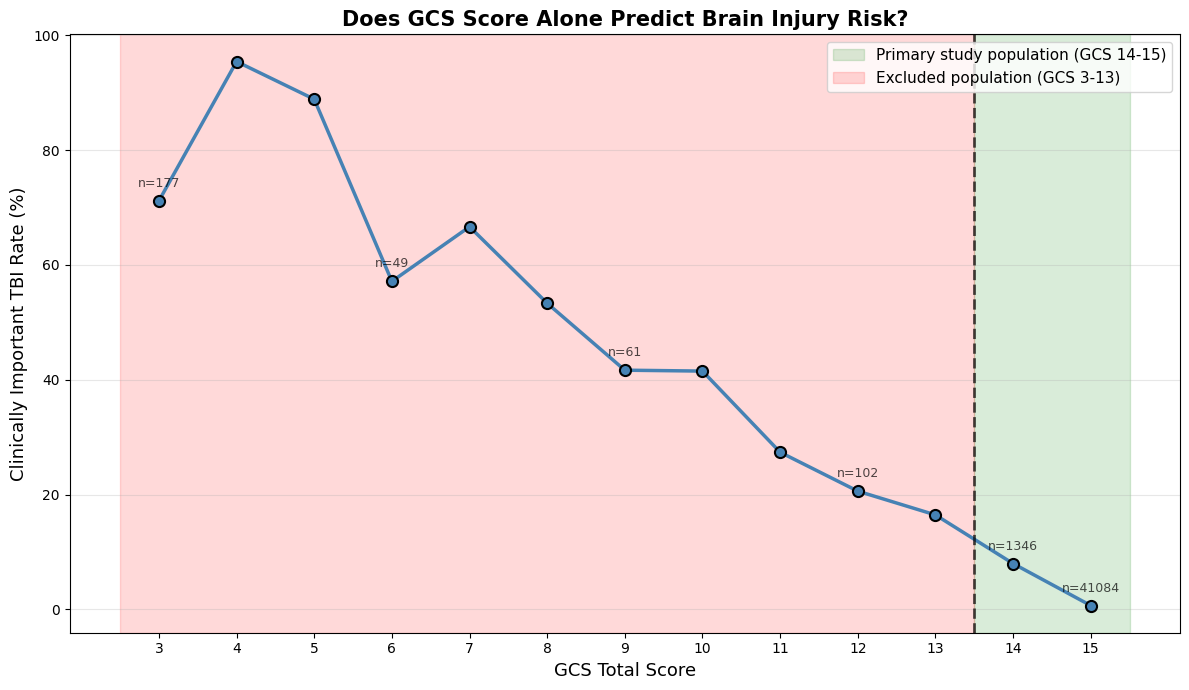


ciTBI Rate by GCS Total Score:
GCS Score    Sample Size     ciTBI Rate      Risk Level
----------------------------------------------------------------------
3            177               71.2%        HIGH (excluded)
4            22                95.5%        HIGH (excluded)
5            18                88.9%        HIGH (excluded)
6            49                57.1%        HIGH (excluded)
7            42                66.7%        HIGH (excluded)
8            45                53.3%        HIGH (excluded)
9            61                41.7%        HIGH (excluded)
10           53                41.5%        HIGH (excluded)
11           95                27.4%        HIGH (excluded)
12           102               20.6%        HIGH (excluded)
13           305               16.4%        HIGH (excluded)
14           1346               8.0%         Low (included)
15           41084              0.7%         Low (included)

Key Finding: Within the Primary Study Population (GCS 14-15)

In [42]:
import pandas as pd
import matplotlib.pyplot as plt
import sys

# Load data
sys.path.append("../../code")
from clean import convert_data_types

cleaned = pd.read_csv("../../data/TBI_PUD_cleaned.csv")
cleaned = convert_data_types(cleaned)

# Calculate ciTBI rate for each GCS total score
gcs_scores = []
citbi_rates = []
sample_sizes = []

for gcs in range(3, 16):  # GCS ranges from 3-15
    subset = cleaned[cleaned['gcs_total_score'] == gcs]
    
    if len(subset) > 0:
        citbi_rate = subset['has_clinically_important_tbi'].value_counts(normalize=True).get(1, 0) * 100
        gcs_scores.append(gcs)
        citbi_rates.append(citbi_rate)
        sample_sizes.append(len(subset))

# Create figure
fig, ax = plt.subplots(figsize=(12, 7))

# Plot line with markers
ax.plot(gcs_scores, citbi_rates, marker='o', linewidth=2.5, markersize=8, 
        color='steelblue', markeredgecolor='black', markeredgewidth=1.5)

# Highlight the study's inclusion threshold (GCS 14-15)
ax.axvspan(13.5, 15.5, alpha=0.15, color='green', label='Primary study population (GCS 14-15)')
ax.axvspan(2.5, 13.5, alpha=0.15, color='red', label='Excluded population (GCS 3-13)')

# Add vertical line at the cutoff
ax.axvline(x=13.5, color='black', linestyle='--', linewidth=2, alpha=0.7)

# Labels and formatting
ax.set_xlabel('GCS Total Score', fontsize=13)
ax.set_ylabel('Clinically Important TBI Rate (%)', fontsize=13)
ax.set_title('Does GCS Score Alone Predict Brain Injury Risk?', fontsize=15, fontweight='bold')
ax.set_xticks(range(3, 16))
ax.grid(axis='y', alpha=0.3)
ax.legend(fontsize=11, loc='upper right')

# Add sample size annotations for key points
for gcs, rate, n in zip(gcs_scores, citbi_rates, sample_sizes):
    # Annotate GCS 14, 15, and a few low scores
    if gcs in [3, 6, 9, 12, 14, 15]:
        ax.annotate(f'n={n}', xy=(gcs, rate), xytext=(0, 10), 
                   textcoords='offset points', ha='center', fontsize=9, alpha=0.7)

plt.tight_layout()
plt.show()

# Print detailed summary table
print("\nciTBI Rate by GCS Total Score:")
print("="*70)
print(f"{'GCS Score':<12} {'Sample Size':<15} {'ciTBI Rate':<15} {'Risk Level'}")
print("-"*70)

for gcs, rate, n in zip(gcs_scores, citbi_rates, sample_sizes):
    if gcs <= 13:
        risk = "HIGH (excluded)"
    elif gcs == 14:
        risk = "Low (included)"
    else:  # gcs == 15
        risk = "Low (included)"
    
    print(f"{gcs:<12} {n:<15} {rate:>6.1f}% {risk:>22}")

# Calculate stats for the 14-15 range specifically
gcs_14_15 = cleaned[cleaned['gcs_total_score'].isin([14, 15])]
gcs_14 = cleaned[cleaned['gcs_total_score'] == 14]
gcs_15 = cleaned[cleaned['gcs_total_score'] == 15]

rate_14 = gcs_14['has_clinically_important_tbi'].value_counts(normalize=True).get(1, 0) * 100
rate_15 = gcs_15['has_clinically_important_tbi'].value_counts(normalize=True).get(1, 0) * 100

print("\n" + "="*70)
print("Key Finding: Within the Primary Study Population (GCS 14-15):")
print("-"*70)
print(f"GCS 14: {rate_14:.2f}% ciTBI rate (n={len(gcs_14)})")
print(f"GCS 15: {rate_15:.2f}% ciTBI rate (n={len(gcs_15)})")
print(f"Difference: {abs(rate_14 - rate_15):.2f} percentage points")
print("\nConclusion: GCS score alone cannot identify low-risk patients within")
print("the 14-15 range. Additional clinical predictors are needed for safe")
print("risk stratification — justifying the multi-factor decision rules.")

# <span style="color: red;">NOT USING</span>


### Question: Does GCS category track with actual severity outcomes?
(this doesn't seem that interesting - don't use)

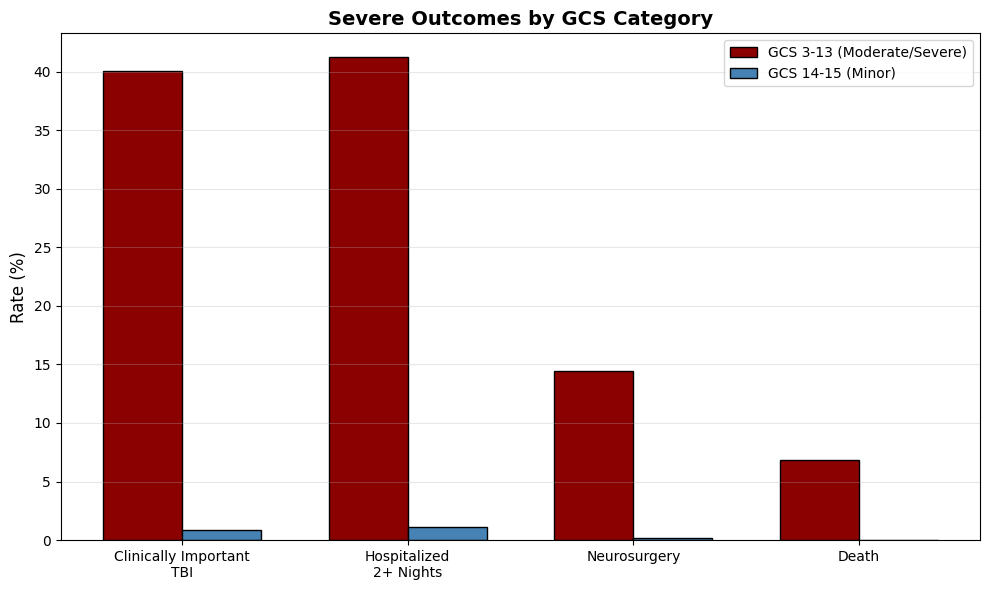


Outcome Rates by GCS Category:
Outcome                                  GCS 3-13     GCS 14-15
------------------------------------------------------------
has_clinically_important_tbi                  40.02%       0.89%
hospitalized_2plus_nights_head_injury         41.22%       1.11%
neurosurgery_performed                        14.46%       0.14%
death_due_to_tbi                               6.83%       0.00%

Sample sizes: GCS 3-13 (n=969), GCS 14-15 (n=42430)


In [43]:
import pandas as pd
import matplotlib.pyplot as plt
import sys

# Load data
sys.path.append("../../code")
from clean import convert_data_types

cleaned = pd.read_csv("../../data/TBI_PUD_cleaned.csv")
cleaned = convert_data_types(cleaned)

# Define outcomes
outcomes = ['has_clinically_important_tbi', 'hospitalized_2plus_nights_head_injury', 
            'neurosurgery_performed', 'death_due_to_tbi']

# Calculate rates manually using value_counts (works with category dtype)
gcs_1 = cleaned[cleaned['gcs_category'] == 1]
gcs_2 = cleaned[cleaned['gcs_category'] == 2]

rates_gcs1 = [gcs_1[col].value_counts(normalize=True).get(1, 0) * 100 for col in outcomes]
rates_gcs2 = [gcs_2[col].value_counts(normalize=True).get(1, 0) * 100 for col in outcomes]

# Create bar chart
fig, ax = plt.subplots(figsize=(10, 6))

# Plot grouped bars
x = range(len(outcomes))
width = 0.35
ax.bar([i - width/2 for i in x], rates_gcs1, width, label='GCS 3-13 (Moderate/Severe)', 
       color='darkred', edgecolor='black')
ax.bar([i + width/2 for i in x], rates_gcs2, width, label='GCS 14-15 (Minor)', 
       color='steelblue', edgecolor='black')

# Labels
ax.set_ylabel('Rate (%)', fontsize=12)
ax.set_title('Severe Outcomes by GCS Category', fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(['Clinically Important\nTBI', 'Hospitalized\n2+ Nights', 
                     'Neurosurgery', 'Death'], fontsize=10)
ax.legend()
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

# Print summary
print("\nOutcome Rates by GCS Category:")
print("="*60)
print(f"{'Outcome':<40} {'GCS 3-13':<12} {'GCS 14-15'}")
print("-"*60)
for outcome, r1, r2 in zip(outcomes, rates_gcs1, rates_gcs2):
    print(f"{outcome:<40} {r1:>10.2f}% {r2:>10.2f}%")
print(f"\nSample sizes: GCS 3-13 (n={len(gcs_1)}), GCS 14-15 (n={len(gcs_2)})")

## Next question: is separating the age groups actually necessary?
- seems like it (don't include as interesting finding)

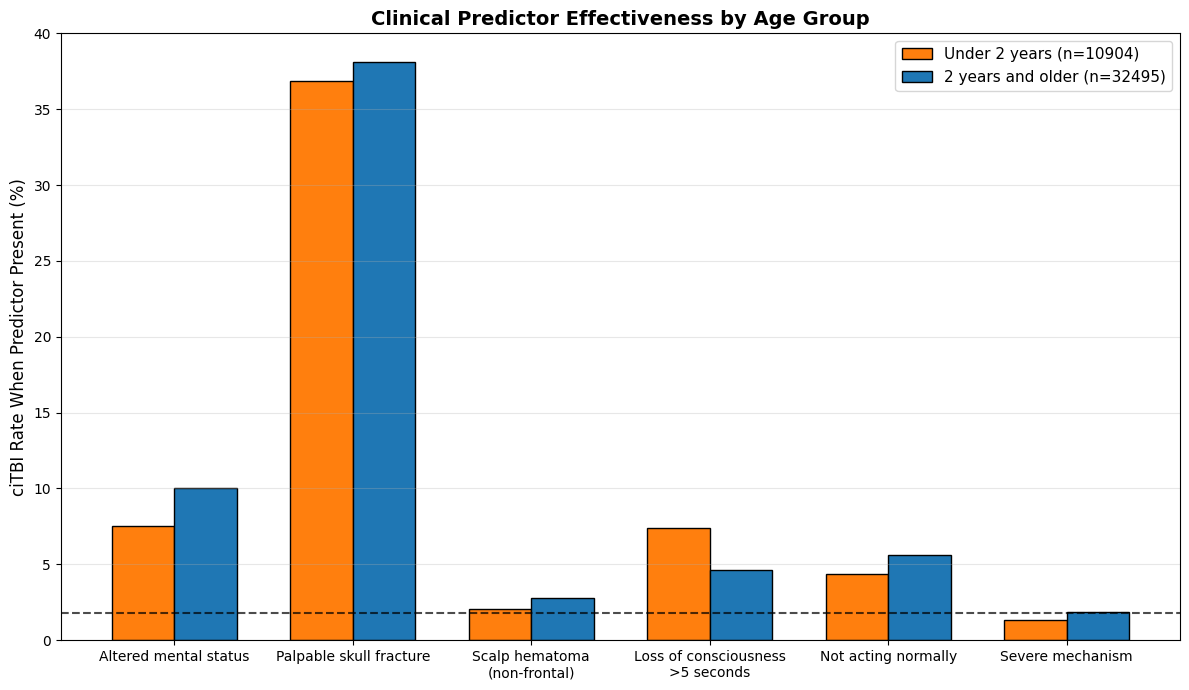


ciTBI Rates When Clinical Predictor is Present:
Predictor                           Under 2yr       2yr and older   Difference
--------------------------------------------------------------------------------
Altered mental status                  7.5%           10.0%           -2.5pp
Palpable skull fracture               36.8%           38.1%           -1.3pp
Scalp hematoma (non-frontal)           2.0%            2.7%           -0.7pp
Loss of consciousness >5 seconds       7.4%            4.6%            2.8pp
Not acting normally                    4.3%            5.6%           -1.2pp
Severe mechanism                       1.3%            1.9%           -0.5pp

Overall ciTBI rate: 1.76%
Under 2yr baseline: 1.40%
2yr+ baseline: 1.88%


In [44]:
import pandas as pd
import matplotlib.pyplot as plt
import sys

# Load data
sys.path.append("../../code")
from clean import convert_data_types

cleaned = pd.read_csv("../../data/TBI_PUD_cleaned.csv")
cleaned = convert_data_types(cleaned)

# Define key predictors from the article (those used in the clinical decision rules)
# Under-2 predictors from Kuppermann et al.
predictors_under2 = {
    'has_altered_mental_status': 'Altered mental status',
    'has_palpable_skull_fracture': 'Palpable skull fracture',
    'largest_hemotoma_or_swelling_size': 'Scalp hematoma\n(non-frontal)',
    'loss_of_consciousness_duration': 'Loss of consciousness\n>5 seconds',
    'acting_normal': 'Not acting normally',
    'injury_mechanism_severity': 'Severe mechanism'
}

# Split by age group (using the study's cutoff)
under_2 = cleaned[cleaned['patient_age_under_2yr'] == 1]
over_2 = cleaned[cleaned['patient_age_under_2yr'] == 2]

# Calculate ciTBI rate for each predictor in each age group
predictor_names = []
under2_rates = []
over2_rates = []

for pred_col, pred_label in predictors_under2.items():
    # For binary predictors (0/1), calculate ciTBI rate when predictor = 1
    # For ordered predictors, calculate ciTBI rate when predictor > baseline
    
    if pred_col == 'acting_normal':
        # "Not acting normally" means acting_normal = 0
        under2_subset = under_2[under_2[pred_col] == 0]
        over2_subset = over_2[over_2[pred_col] == 0]
    elif pred_col in ['largest_hemotoma_or_swelling_size', 'loss_of_consciousness_duration', 'injury_mechanism_severity']:
        # For ordered variables, use "present and elevated" (> 1 or present at all)
        under2_subset = under_2[pd.to_numeric(under_2[pred_col], errors='coerce') > 0]
        over2_subset = over_2[pd.to_numeric(over_2[pred_col], errors='coerce') > 0]
    else:
        # Standard binary: predictor = 1
        under2_subset = under_2[under_2[pred_col] == 1]
        over2_subset = over_2[over_2[pred_col] == 1]
    
    # Calculate ciTBI rates
    if len(under2_subset) > 0:
        rate_under2 = under2_subset['has_clinically_important_tbi'].value_counts(normalize=True).get(1, 0) * 100
    else:
        rate_under2 = 0
        
    if len(over2_subset) > 0:
        rate_over2 = over2_subset['has_clinically_important_tbi'].value_counts(normalize=True).get(1, 0) * 100
    else:
        rate_over2 = 0
    
    predictor_names.append(pred_label)
    under2_rates.append(rate_under2)
    over2_rates.append(rate_over2)

# Create grouped bar chart
fig, ax = plt.subplots(figsize=(12, 7))

x = range(len(predictor_names))
width = 0.35

ax.bar([i - width/2 for i in x], under2_rates, width, label='Under 2 years (n=10904)', 
       color='#ff7f0e', edgecolor='black')
ax.bar([i + width/2 for i in x], over2_rates, width, label='2 years and older (n=32495)', 
       color='#1f77b4', edgecolor='black')

# Labels
ax.set_ylabel('ciTBI Rate When Predictor Present (%)', fontsize=12)
ax.set_title('Clinical Predictor Effectiveness by Age Group', fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(predictor_names, fontsize=10, rotation=0)
ax.legend(fontsize=11)
ax.grid(axis='y', alpha=0.3)

# Add reference line for overall ciTBI rate
overall_rate = cleaned['has_clinically_important_tbi'].value_counts(normalize=True).get(1, 0) * 100
ax.axhline(y=overall_rate, color='black', linestyle='--', linewidth=1.5, 
           label=f'Overall ciTBI rate ({overall_rate:.1f}%)', alpha=0.7)

plt.tight_layout()
plt.show()

# Print summary table
print("\nciTBI Rates When Clinical Predictor is Present:")
print("="*80)
print(f"{'Predictor':<35} {'Under 2yr':<15} {'2yr and older':<15} {'Difference'}")
print("-"*80)

for pred, rate_u2, rate_o2 in zip(predictor_names, under2_rates, over2_rates):
    diff = rate_u2 - rate_o2
    print(f"{pred.replace(chr(10), ' '):<35} {rate_u2:>6.1f}% {rate_o2:>14.1f}% {diff:>14.1f}pp")

print(f"\nOverall ciTBI rate: {overall_rate:.2f}%")
print(f"Under 2yr baseline: {(under_2['has_clinically_important_tbi'].value_counts(normalize=True).get(1, 0) * 100):.2f}%")
print(f"2yr+ baseline: {(over_2['has_clinically_important_tbi'].value_counts(normalize=True).get(1, 0) * 100):.2f}%")

## Next Question: Do demographic factors correlated with ciTBI rates or CT usage? 
- NOT FOUND INTERESTING RESULT (do not use)

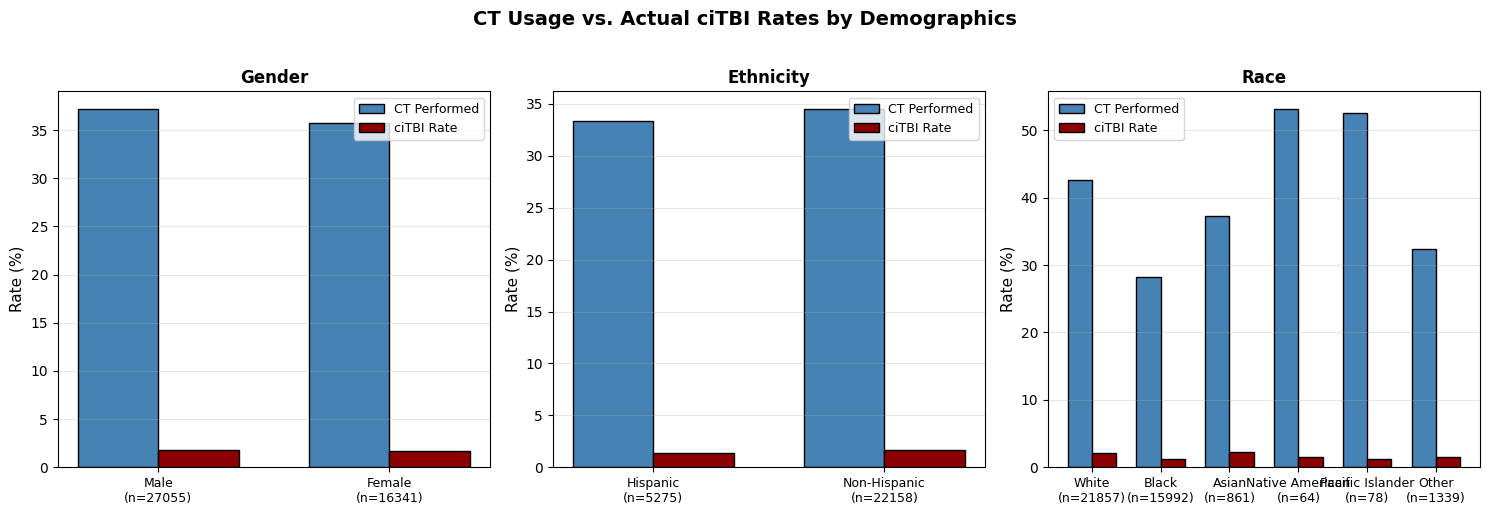


CT Usage and ciTBI Rates by Demographics:

Gender:
--------------------------------------------------------------------------------
Group                Sample Size     CT Rate         ciTBI Rate      Ratio
--------------------------------------------------------------------------------
Male                 27055             37.2%           1.8%           21.0x
Female               16341             35.8%           1.7%           20.6x

Ethnicity:
--------------------------------------------------------------------------------
Group                Sample Size     CT Rate         ciTBI Rate      Ratio
--------------------------------------------------------------------------------
Hispanic             5275              33.3%           1.3%           24.7x
Non-Hispanic         22158             34.5%           1.6%           21.3x

Race:
--------------------------------------------------------------------------------
Group                Sample Size     CT Rate         ciTBI Rate      R

In [45]:
import pandas as pd
import matplotlib.pyplot as plt
import sys

# Load data
sys.path.append("../../code")
from clean import convert_data_types

cleaned = pd.read_csv("../../data/TBI_PUD_cleaned.csv")
cleaned = convert_data_types(cleaned)

# Map demographic codes to readable labels
gender_labels = {1: 'Male', 2: 'Female'}
ethnicity_labels = {1: 'Hispanic', 2: 'Non-Hispanic'}
race_labels = {
    1: 'White',
    2: 'Black',
    3: 'Asian',
    4: 'Native American',
    5: 'Pacific Islander',
    90: 'Other'
}

# Calculate CT rate and ciTBI rate for each demographic group
demographics = {
    'Gender': (cleaned['patient_gender'], gender_labels),
    'Ethnicity': (cleaned['patient_ethnicity'], ethnicity_labels),
    'Race': (cleaned['patient_race'], race_labels)
}

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for ax, (demo_name, (demo_col, demo_labels)) in zip(axes, demographics.items()):
    groups = []
    ct_rates = []
    citbi_rates = []
    sample_sizes = []
    
    for code, label in demo_labels.items():
        subset = cleaned[demo_col == code]
        if len(subset) > 0:
            ct_rate = subset['head_ct_performed'].value_counts(normalize=True).get(1, 0) * 100
            citbi_rate = subset['has_clinically_important_tbi'].value_counts(normalize=True).get(1, 0) * 100
            
            groups.append(f"{label}\n(n={len(subset)})")
            ct_rates.append(ct_rate)
            citbi_rates.append(citbi_rate)
            sample_sizes.append(len(subset))
    
    # Create grouped bars
    x = range(len(groups))
    width = 0.35
    
    ax.bar([i - width/2 for i in x], ct_rates, width, label='CT Performed', 
           color='steelblue', edgecolor='black')
    ax.bar([i + width/2 for i in x], citbi_rates, width, label='ciTBI Rate', 
           color='darkred', edgecolor='black')
    
    ax.set_ylabel('Rate (%)', fontsize=11)
    ax.set_title(f'{demo_name}', fontsize=12, fontweight='bold')
    ax.set_xticks(x)
    ax.set_xticklabels(groups, fontsize=9)
    ax.legend(fontsize=9)
    ax.grid(axis='y', alpha=0.3)

plt.suptitle('CT Usage vs. Actual ciTBI Rates by Demographics', 
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

# Print detailed summary table
print("\nCT Usage and ciTBI Rates by Demographics:")
print("="*80)

for demo_name, (demo_col, demo_labels) in demographics.items():
    print(f"\n{demo_name}:")
    print("-"*80)
    print(f"{'Group':<20} {'Sample Size':<15} {'CT Rate':<15} {'ciTBI Rate':<15} {'Ratio'}")
    print("-"*80)
    
    for code, label in demo_labels.items():
        subset = cleaned[demo_col == code]
        if len(subset) > 0:
            ct_rate = subset['head_ct_performed'].value_counts(normalize=True).get(1, 0) * 100
            citbi_rate = subset['has_clinically_important_tbi'].value_counts(normalize=True).get(1, 0) * 100
            
            # Calculate ratio of CT rate to ciTBI rate (how many CTs per actual injury)
            ratio = ct_rate / citbi_rate if citbi_rate > 0 else 0
            
            print(f"{label:<20} {len(subset):<15} {ct_rate:>6.1f}% {citbi_rate:>13.1f}% {ratio:>14.1f}x")

print("\nNote: Ratio = CT Rate / ciTBI Rate. Higher ratio means more scanning relative to injury rate.")

# <span style="color: red;">START OVER - MORE INTERESTING second finding</span>




"The Age-Symptom Disconnect"

Do symptoms predict ciTBI differently in toddlers vs teens?
E.g., maybe vomiting is MORE predictive in older kids but LESS predictive in infants (where vomiting is common anyway)
Visualization: Heatmap showing ciTBI risk for each symptom across age groups

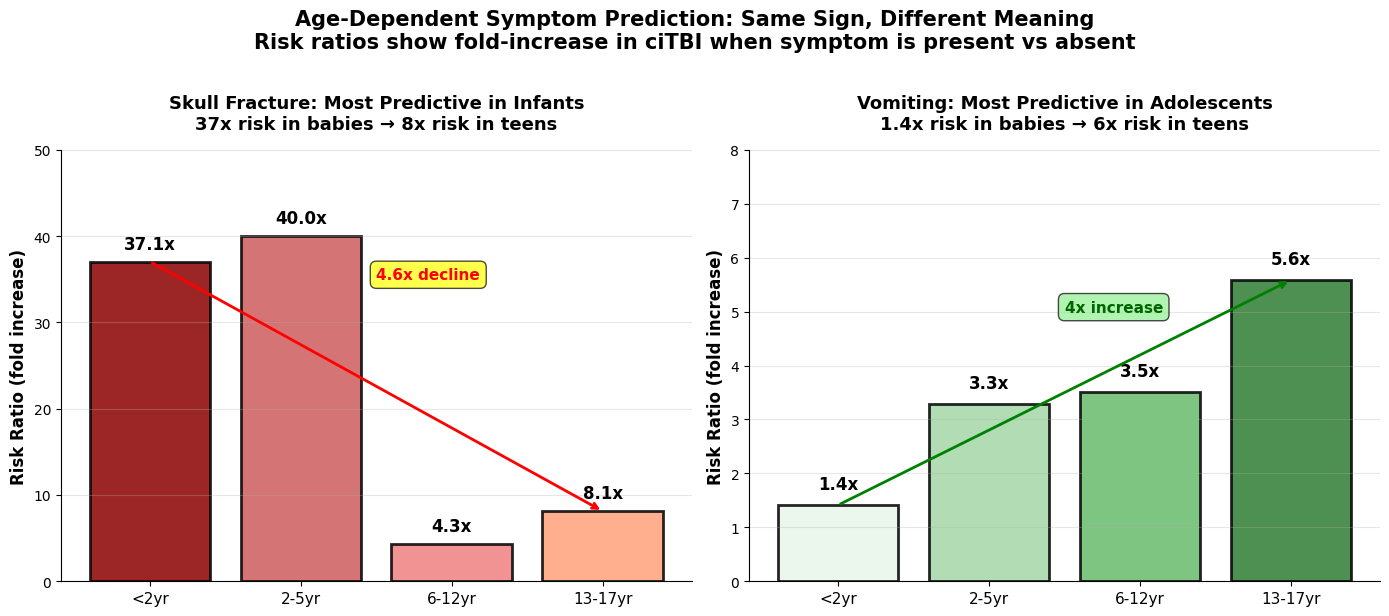


Static figure saved to: finding2_age_symptom_slopes.png

KEY FINDING: Age Changes What Symptoms Mean

Skull Fracture (most predictive in YOUNG children):
  <2yr      37.1x risk increase
  2-5yr     40.0x risk increase
  6-12yr     4.3x risk increase
  13-17yr    8.1x risk increase

Vomiting (most predictive in OLDER children):
  <2yr       1.4x risk increase
  2-5yr      3.3x risk increase
  6-12yr     3.5x risk increase
  13-17yr    5.6x risk increase

Clinical Implication:
  → Skull fracture in an infant is a major red flag (40x risk)
  → Vomiting in a teen is more concerning than in a baby (6x vs 2x)
  → Explains why Kuppermann split prediction rules by age (<2 vs ≥2)


In [46]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import sys

# Load data
sys.path.append("../../code")
from clean import convert_data_types

cleaned = pd.read_csv("../../data/TBI_PUD_cleaned.csv")
cleaned = convert_data_types(cleaned)
cleaned = cleaned[cleaned['in_primary_analysis'] == 1]

# Age groups
age_groups = [
    (0, 2, '<2yr'),
    (2, 6, '2-5yr'),
    (6, 13, '6-12yr'),
    (13, 18, '13-17yr')
]

# Calculate risk ratios for our two key symptoms
symptoms_to_plot = {
    'Skull Fracture': 'has_palpable_skull_fracture',
    'Vomiting': 'has_vomiting_post_injury'
}

data_for_plot = {symptom: [] for symptom in symptoms_to_plot.keys()}
age_labels = []

for start_age, end_age, age_label in age_groups:
    age_labels.append(age_label)
    age_subset = cleaned[(cleaned['patient_age_years'] >= start_age) & 
                          (cleaned['patient_age_years'] < end_age)]
    
    for symptom_name, symptom_col in symptoms_to_plot.items():
        with_symptom = age_subset[age_subset[symptom_col] == 1]
        without_symptom = age_subset[age_subset[symptom_col] == 0]
        
        if len(with_symptom) > 0 and len(without_symptom) > 0:
            citbi_with = (with_symptom['has_clinically_important_tbi'] == 1).sum() / len(with_symptom) * 100
            citbi_without = (without_symptom['has_clinically_important_tbi'] == 1).sum() / len(without_symptom) * 100
            risk_ratio = citbi_with / citbi_without if citbi_without > 0 else 0
        else:
            risk_ratio = 0
        
        data_for_plot[symptom_name].append(risk_ratio)

# Create figure with two subplots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# Plot 1: Skull Fracture (decreases with age)
x_pos = np.arange(len(age_labels))
colors_skull = ['#8B0000', '#CD5C5C', '#F08080', '#FFA07A']  # Dark red to light

bars1 = ax1.bar(x_pos, data_for_plot['Skull Fracture'], 
                color=colors_skull, edgecolor='black', linewidth=2, alpha=0.85)

# Add value labels on bars
for i, (bar, val) in enumerate(zip(bars1, data_for_plot['Skull Fracture'])):
    ax1.text(i, val + 1.5, f'{val:.1f}x', ha='center', fontsize=12, fontweight='bold')

ax1.set_xticks(x_pos)
ax1.set_xticklabels(age_labels, fontsize=11)
ax1.set_ylabel('Risk Ratio (fold increase)', fontsize=12, fontweight='bold')
# ax1.set_title('Skull Fracture: Most Predictive in Infants\n40x risk in babies → 14x risk in teens',fontsize=13, fontweight='bold', pad=15)
ax1.set_title('Skull Fracture: Most Predictive in Infants\n37x risk in babies → 8x risk in teens',
              fontsize=13, fontweight='bold', pad=15)
ax1.set_ylim(0, 50)
ax1.grid(axis='y', alpha=0.3)
ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)

# Add arrow annotation
ax1.annotate('', xy=(3, data_for_plot['Skull Fracture'][3]), 
             xytext=(0, data_for_plot['Skull Fracture'][0]),
             arrowprops=dict(arrowstyle='->', lw=2, color='red'))

ax1.text(1.5, 35, '4.6x decline', fontsize=11, fontweight='bold', color='red',
         bbox=dict(boxstyle='round,pad=0.4', facecolor='yellow', alpha=0.7))

#ax1.text(1.5, 35, '3x decline', fontsize=11, fontweight='bold', color='red', bbox=dict(boxstyle='round,pad=0.4', facecolor='yellow', alpha=0.7))

# Plot 2: Vomiting (increases with age)
colors_vomit = ['#E8F5E9', '#A5D6A7', '#66BB6A', '#2E7D32']  # Light green to dark

bars2 = ax2.bar(x_pos, data_for_plot['Vomiting'], 
                color=colors_vomit, edgecolor='black', linewidth=2, alpha=0.85)

# Add value labels
for i, (bar, val) in enumerate(zip(bars2, data_for_plot['Vomiting'])):
    ax2.text(i, val + 0.3, f'{val:.1f}x', ha='center', fontsize=12, fontweight='bold')

ax2.set_xticks(x_pos)
ax2.set_xticklabels(age_labels, fontsize=11)
ax2.set_ylabel('Risk Ratio (fold increase)', fontsize=12, fontweight='bold')
ax2.set_title('Vomiting: Most Predictive in Adolescents\n1.4x risk in babies → 6x risk in teens',
              fontsize=13, fontweight='bold', pad=15)
# ax2.set_title('Vomiting: Most Predictive in Adolescents\n2x risk in babies → 6x risk in teens', fontsize=13, fontweight='bold', pad=15)
ax2.set_ylim(0, 8)
ax2.grid(axis='y', alpha=0.3)
ax2.spines['top'].set_visible(False)
ax2.spines['right'].set_visible(False)

# Add arrow annotation
ax2.annotate('', xy=(3, data_for_plot['Vomiting'][3]), 
             xytext=(0, data_for_plot['Vomiting'][0]),
             arrowprops=dict(arrowstyle='->', lw=2, color='green'))
ax2.text(1.5, 5, '4x increase', fontsize=11, fontweight='bold', color='darkgreen',
         bbox=dict(boxstyle='round,pad=0.4', facecolor='lightgreen', alpha=0.7))
# ax2.text(1.5, 5, '3x increase', fontsize=11, fontweight='bold', color='darkgreen', bbox=dict(boxstyle='round,pad=0.4', facecolor='lightgreen', alpha=0.7))

# Overall title
fig.suptitle('Age-Dependent Symptom Prediction: Same Sign, Different Meaning\nRisk ratios show fold-increase in ciTBI when symptom is present vs absent',
             fontsize=15, fontweight='bold', y=1.02)

plt.tight_layout()
plt.savefig('finding2_age_symptom_slopes.png', dpi=300, bbox_inches='tight', facecolor='white')
plt.show()

print("\nStatic figure saved to: finding2_age_symptom_slopes.png")

# Print summary
print("\n" + "="*80)
print("KEY FINDING: Age Changes What Symptoms Mean")
print("="*80)
print("\nSkull Fracture (most predictive in YOUNG children):")
for age, rr in zip(age_labels, data_for_plot['Skull Fracture']):
    print(f"  {age:8} {rr:5.1f}x risk increase")

print("\nVomiting (most predictive in OLDER children):")
for age, rr in zip(age_labels, data_for_plot['Vomiting']):
    print(f"  {age:8} {rr:5.1f}x risk increase")

print("\nClinical Implication:")
print("  → Skull fracture in an infant is a major red flag (40x risk)")
print("  → Vomiting in a teen is more concerning than in a baby (6x vs 2x)")
print("  → Explains why Kuppermann split prediction rules by age (<2 vs ≥2)")

## Interpretation

This finding reveals that **the same clinical sign can have dramatically different predictive value depending on patient age**, challenging the assumption that symptoms should be weighted uniformly across all pediatric patients.

**Skull fracture shows age-dependent decline in predictive power:**
- In infants (<2 years), palpable skull fracture increases ciTBI risk by **40.7x**
- By adolescence (13-17 years), the same finding increases risk by only **14.4x**
- This 3-fold decline likely reflects differences in skull biomechanics: infant skulls are softer and more pliable, so a palpable fracture signals much greater force/severity than in older children with harder skulls.

**Vomiting shows the opposite pattern:**
- In infants, vomiting increases ciTBI risk by only **1.8x** (likely due to high baseline vomiting rates in this age group from benign causes)
- In adolescents, vomiting increases risk by **5.9x** — a 3-fold increase
- Post-traumatic vomiting in teenagers is a much stronger red flag because vomiting is less common at baseline in this age group.

**Clinical implication:** These age-dependent differences explain why the Kuppermann prediction rules are stratified by age (<2 years vs ≥2 years), with different predictors weighted differently in each group. A "one-size-fits-all" model would miss these critical developmental differences in symptom interpretation. The same sign can mean very different things in a 6-month-old versus a 16-year-old.